In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# ================== CONFIG ==================
DATA_DIR = "../Datasets/archive/Teeth_DataSet/Teeth_Dataset"
TESTING_DIR = os.path.join(DATA_DIR, "Testing")

IMG_SIZE = 224
BATCH_SIZE = 32

CLASSES = ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
MODEL_PATH = "teeth_case_based_model.h5"

print("Loading model:", MODEL_PATH)

model = tf.keras.models.load_model(MODEL_PATH)





Loading model: teeth_case_based_model.h5


In [3]:
# ================== LOAD TEST DATA ==================
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TESTING_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASSES,
    shuffle=False
)

print("Test samples:", test_generator.samples)




Found 1028 images belonging to 7 classes.
Test samples: 1028


In [4]:
# ================== EVALUATE ==================
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print("\n==================== EVALUATION RESULT ====================")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")




33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 595ms/step - accuracy: 0.9912 - loss: 0.0256

==================== EVALUATION RESULT ====================
Test Loss: 0.0256
Test Accuracy: 0.9912


In [5]:
# ================== PREDICT ==================
test_generator.reset()
y_pred = model.predict(test_generator, verbose=1)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes



33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 608ms/step


In [6]:

# ================== CLASSIFICATION REPORT ==================
print("\n==================== CLASSIFICATION REPORT ====================")
print(classification_report(y_true, y_pred_classes, target_names=CLASSES))




==================== CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

         CaS       1.00      1.00      1.00       160
         CoS       1.00      1.00      1.00       149
         Gum       1.00      0.99      1.00       120
          MC       0.97      0.99      0.98       180
          OC       0.96      0.97      0.97       108
         OLP       1.00      0.98      0.99       180
          OT       1.00      1.00      1.00       131

    accuracy                           0.99      1028
   macro avg       0.99      0.99      0.99      1028
weighted avg       0.99      0.99      0.99      1028




Confusion matrix saved as: confusion_matrix.png


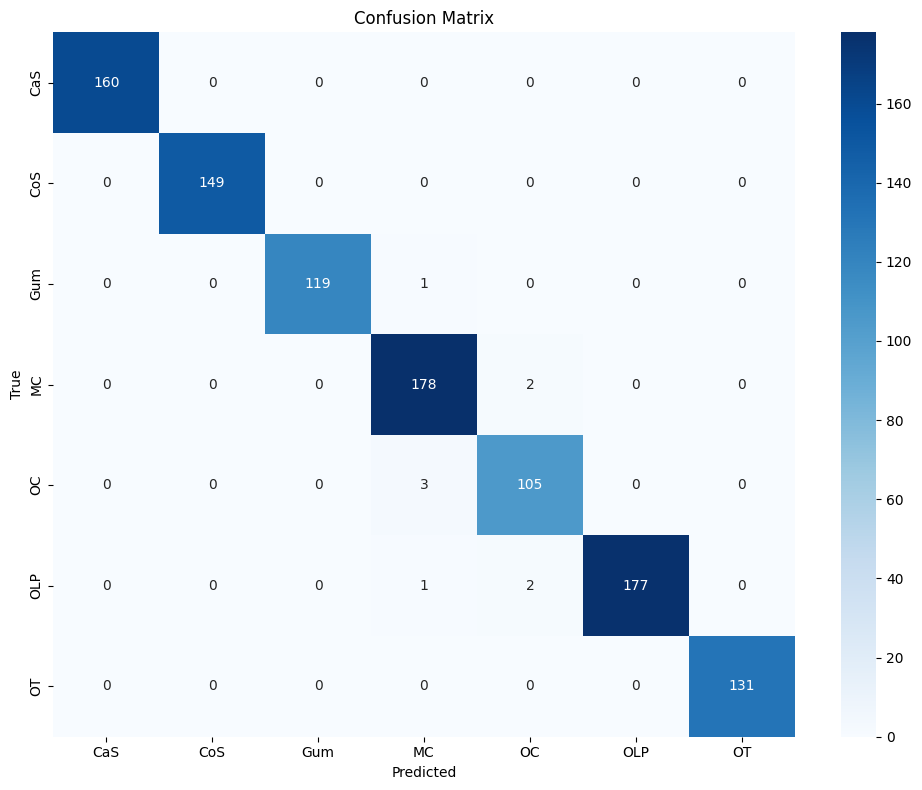

In [7]:

# ================== CONFUSION MATRIX ==================
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300)
print("\nConfusion matrix saved as: confusion_matrix.png")

plt.show()